# Model Definition and Evaluation
## Table of Contents
1. [Model Selection](#model-selection)
2. [Feature Engineering](#feature-engineering)
3. [Hyperparameter Tuning](#hyperparameter-tuning)
4. [Implementation](#implementation)
5. [Evaluation Metrics](#evaluation-metrics)
6. [Comparative Analysis](#comparative-analysis)


In [7]:
# Import necessary libraries
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from datasets import concatenate_datasets, load_dataset
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedGroupKFold
from torch.utils.data import DataLoader
from torchvision.models import ResNet50_Weights, resnet50
# Import models you're considering
# We considered the custom baseline CNN, an Optuna-tuned CNN, ResNet50 transfer learning,
# AlexNet transfer learning, and an HSV variant. The final implementation uses ResNet50.



## Model Selection

[Discuss the type(s) of models you consider for this task, and justify the selection.]

We considered five model variants based on the experiments in `3_Model/experiments`:

1. A custom CNN baseline trained directly on the image pixels.
2. The same CNN with stratified grouped k-fold cross-validation.
3. An Optuna-tuned CNN with configurable convolutional depth, filters, dropout, learning rate, resolution, and batch size.
4. Transfer learning with ImageNet-pretrained ResNet50.
5. Transfer learning with ImageNet-pretrained AlexNet, plus an HSV color-space variant.

The final model is the ImageNet-normalized ResNet50 transfer-learning model. It is appropriate because the task is image classification and ResNet50 already contains strong general visual features learned from a large image corpus. We freeze the pretrained feature extractor and replace only the final classification layer with an 8-class output layer for the aesthetic emotion labels. This keeps training feasible for the seminar project while improving on the simpler baseline CNN. AlexNet and HSV preprocessing were tested as alternatives, but their validation/test metrics did not improve over the ResNet50 result.


## Feature Engineering

[Describe any additional feature engineering you've performed beyond what was done for the baseline model.]

The model still uses the images themselves as input features, but the preprocessing changed from the baseline setup. For ResNet50 transfer learning we resize/consume RGB images as tensors and normalize them with the ImageNet mean and standard deviation expected by the pretrained weights. During training we add light image augmentation with random horizontal flips and small rotations. These transformations are the image-classification equivalent of feature engineering: they expose the model to plausible visual variation without changing the target label.

We also tested an RGB-to-HSV conversion, but it did not improve the metrics. Because the chosen ResNet50 weights were pretrained on RGB ImageNet images, the final workflow keeps RGB inputs and ImageNet normalization.


In [8]:
# Load the dataset
# Replace 'your_dataset.csv' with the path to your actual dataset
# The project data is hosted as a Hugging Face image dataset, not as a local CSV.
dataset = load_dataset("bjoern-doege/aesthetic-emotions-map")

# Perform any feature engineering steps
# Example: df['new_feature'] = df['feature1'] + df['feature2']
# For image classification, feature engineering is implemented as image transforms.
NORMALIZE_MEAN = [0.485, 0.456, 0.406]
NORMALIZE_STD = [0.229, 0.224, 0.225]

TRAIN_TRANSFORM = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
])

VAL_TRANSFORM = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
])

# Feature and target variable selection
# X contains image indices; the actual image tensors are created lazily by the transforms.
label_names = sorted(dataset["train"].unique("label"))
label_to_id = {label: i for i, label in enumerate(label_names)}
id_to_label = {i: label for label, i in label_to_id.items()}

trainval_dataset = concatenate_datasets([
    dataset["train"],
    dataset["validation"],
])
test_dataset = dataset["test"]

X = np.arange(len(trainval_dataset))
y = [label_to_id[label] for label in trainval_dataset["label"]]
groups = trainval_dataset["style"]

# Split the dataset
# Instead of a random train_test_split, we use StratifiedGroupKFold on train+validation
# and keep the provided test split untouched for final evaluation.
N_SPLITS = 5
RANDOM_STATE = 42
cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

style_overlap = set(trainval_dataset["style"]) & set(test_dataset["style"])
print(f"Train+validation samples: {len(trainval_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {label_names}")
print(f"Overlapping styles between train+validation and test: {len(style_overlap)}")



Resolving data files:   0%|          | 0/4721 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1025 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1089 [00:00<?, ?it/s]

Train+validation samples: 5744
Test samples: 1088
Classes: ['aesthetic_emptiness', 'energetic_playfulness', 'intellectual_unease', 'lighthearted_humor', 'melancholic', 'pure_calm', 'serene_beauty', 'sublime_activation']
Overlapping styles between train+validation and test: 0


## Hyperparameter Tuning

[Discuss any hyperparameter tuning methods you've applied, such as Grid Search or Random Search, and the rationale behind them.]

For the custom CNN experiments, we used Optuna to explore model depth, filter sizes, kernel sizes, dropout, fully connected layer size, learning rate, image resolution, and batch size. These trials helped us understand which training choices mattered, but the tuned custom CNN still did not outperform the transfer-learning models.

For the final model, we selected the ResNet50 transfer-learning setup that performed best in the previous experiments: ImageNet normalization, frozen pretrained feature layers, a new 8-class classification head, Adam optimizer with a learning rate of 0.001, weighted cross-entropy for class imbalance, 10 training epochs, batch size 64, and 5-fold stratified grouped cross-validation.



In [9]:
# Implement hyperparameter tuning
# Example using GridSearchCV with a DecisionTreeClassifier
# param_grid = {'max_depth': [2, 4, 6, 8]}
# grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
# grid_search.fit(X_train, y_train)

# For the selected PyTorch CNN workflow, grouped k-fold validation is used.
# The notebook loads completed ResNet50 fold metrics from milestone 2, or trains
# the folds if those artifacts are missing.
BATCH_SIZE = 64
LEARNING_RATE = 0.001
NUM_EPOCHS = 10
ARTIFACT_DIR = Path("3_Model/experiments") if Path("3_Model/experiments").is_dir() else Path("experiments")
MODEL_PATH = ARTIFACT_DIR / "model_seed_42_w_k-fold_transfer_learning_resnet50_imagenet_normalized.pth"
FOLD_METRICS_PATH = ARTIFACT_DIR / "fold_metrics_seed_42_w_k-fold_transfer_learning_resnet50_imagenet_normalized.csv"
EVAL_METRICS_PATH = ARTIFACT_DIR / "eval_eval_metrics_seed_42_w_k-fold_transfer_learning_resnet50_imagenet_normalized.csv"
HUMAN_BASELINE_PATH = Path("3_Model/aem_human_baseline_2026_06_25_a.csv")
if not HUMAN_BASELINE_PATH.exists():
    HUMAN_BASELINE_PATH = Path("aem_human_baseline_2026_06_25_a.csv")

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Using Device: {DEVICE}")


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


seed_everything(RANDOM_STATE)


def preprocess_train(examples):
    return {
        "image": [TRAIN_TRANSFORM(image.convert("RGB")) for image in examples["image"]],
        "label": torch.tensor([label_to_id[label] for label in examples["label"]], dtype=torch.long),
    }


def preprocess_val(examples):
    return {
        "image": [VAL_TRANSFORM(image.convert("RGB")) for image in examples["image"]],
        "label": torch.tensor([label_to_id[label] for label in examples["label"]], dtype=torch.long),
    }


def create_dataloader(ds, batch_size=BATCH_SIZE, train=False, shuffle=False, seed=RANDOM_STATE):
    generator = None
    if shuffle:
        generator = torch.Generator()
        generator.manual_seed(seed)

    return DataLoader(
        ds.with_transform(preprocess_train if train else preprocess_val),
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        generator=generator,
    )


def compute_class_weights(ds):
    labels = [label_to_id[label] for label in ds["label"]]
    class_counts = np.bincount(labels, minlength=len(label_names))
    class_counts = np.maximum(class_counts, 1)
    weights = len(labels) / (len(label_names) * class_counts)
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)


def create_loss_fn(ds):
    return nn.CrossEntropyLoss(weight=compute_class_weights(ds))


def compute_metrics(y_true, y_pred, total_loss):
    return {
        "loss": total_loss / len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "y_true": y_true,
        "y_pred": y_pred,
    }




Using Device: mps


## Implementation

[Implement the final model(s) you've selected based on the above steps.]

The final model uses ImageNet-pretrained ResNet50. All pretrained layers are frozen and the final fully connected layer is replaced with a new `Linear` layer with eight outputs, one for each aesthetic emotion class. The training loop uses weighted cross-entropy to compensate for class imbalance and Adam for optimization. If the saved milestone 2 model and metrics are present, the notebook loads them; otherwise, it can retrain using the same procedure.


In [10]:
# Implement the final model(s)
# Example: model = YourChosenModel(best_hyperparameters)
# model.fit(X_train, y_train)


def update_model_last_layer(model, num_classes):
    """Freeze ResNet50 feature layers and replace the classification head."""
    for name, param in model.named_parameters():
        if not name.startswith("fc."):
            param.requires_grad = False

    num_features = model.fc.in_features
    model.fc = nn.Linear(in_features=num_features, out_features=num_classes)
    return model


def create_model():
    weights = ResNet50_Weights.DEFAULT
    model = resnet50(weights=weights)
    model = update_model_last_layer(model, num_classes=len(label_names))
    return model.to(DEVICE)


def create_optimizer(model):
    return optim.Adam(model.parameters(), lr=LEARNING_RATE)


def train_one_epoch(model, train_loader, optimizer, loss_fn, device):
    model.train()
    running_loss = 0.0
    y_true = []
    y_pred = []

    for batch in train_loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        predicted = outputs.argmax(dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

    return compute_metrics(y_true, y_pred, running_loss)


def evaluate(model, data_loader, loss_fn, device):
    model.eval()
    running_loss = 0.0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for batch in data_loader:
            images = batch["image"].to(device)
            labels = batch["label"].to(device)

            outputs = model(images)
            loss = loss_fn(outputs, labels)

            running_loss += loss.item() * images.size(0)
            predicted = outputs.argmax(dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    return compute_metrics(y_true, y_pred, running_loss)


if MODEL_PATH.exists() and FOLD_METRICS_PATH.exists():
    print(f"Found {MODEL_PATH}; loading saved cross-validation metrics.")
    fold_metrics = pd.read_csv(FOLD_METRICS_PATH).to_dict(orient="records")
    cv_splits = []
else:
    print("Saved model or fold metrics missing; running grouped k-fold training.")
    fold_metrics = []
    cv_splits = cv.split(X, y, groups)

for fold, (train_idx, val_idx) in enumerate(cv_splits, start=1):
    print(f"\nFold {fold}/{N_SPLITS}")
    fold_seed = RANDOM_STATE + fold
    seed_everything(fold_seed)

    fold_train_dataset = trainval_dataset.select(train_idx.tolist())
    fold_val_dataset = trainval_dataset.select(val_idx.tolist())
    train_loader = create_dataloader(fold_train_dataset, train=True, shuffle=True, seed=fold_seed)
    val_loader = create_dataloader(fold_val_dataset, train=False, shuffle=False)

    model = create_model()
    optimizer = create_optimizer(model)
    loss_fn = create_loss_fn(fold_train_dataset)

    for epoch in range(NUM_EPOCHS):
        train_metrics = train_one_epoch(model, train_loader, optimizer, loss_fn, DEVICE)
        val_metrics = evaluate(model, val_loader, loss_fn, DEVICE)
        print(
            f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
            f"train_loss={train_metrics['loss']:.4f}, "
            f"train_acc={train_metrics['accuracy']:.4f}, "
            f"train_macro_f1={train_metrics['f1_macro']:.4f}, "
            f"train_weighted_f1={train_metrics['f1_weighted']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f}, "
            f"val_acc={val_metrics['accuracy']:.4f}, "
            f"val_macro_f1={val_metrics['f1_macro']:.4f}, "
            f"val_weighted_f1={val_metrics['f1_weighted']:.4f}"
        )
        fold_metrics.append({
            "fold": fold,
            "epoch": epoch + 1,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "train_f1_weighted": train_metrics["f1_weighted"],
            "train_f1_macro": train_metrics["f1_macro"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_f1_weighted": val_metrics["f1_weighted"],
            "val_f1_macro": val_metrics["f1_macro"],
        })

if cv_splits != []:
    pd.DataFrame(fold_metrics).to_csv(FOLD_METRICS_PATH, index=False)

fold_metrics_df = pd.DataFrame(fold_metrics)
last_epoch_folds = fold_metrics_df.loc[fold_metrics_df.groupby("fold")["epoch"].idxmax()]
print("\nCross-validation summary from final fold epochs")
print(f"Accuracy: {last_epoch_folds['val_accuracy'].mean():.4f} +/- {last_epoch_folds['val_accuracy'].std(ddof=0):.4f}")
print(f"Macro F1: {last_epoch_folds['val_f1_macro'].mean():.4f} +/- {last_epoch_folds['val_f1_macro'].std(ddof=0):.4f}")
print(f"Weighted F1: {last_epoch_folds['val_f1_weighted'].mean():.4f} +/- {last_epoch_folds['val_f1_weighted'].std(ddof=0):.4f}")



Found experiments/model_seed_42_w_k-fold_transfer_learning_resnet50_imagenet_normalized.pth; loading saved cross-validation metrics.

Cross-validation summary from final fold epochs
Accuracy: 0.4775 +/- 0.0268
Macro F1: 0.4449 +/- 0.0272
Weighted F1: 0.4833 +/- 0.0273


## Evaluation Metrics

[Clearly specify which metrics you'll use to evaluate the model performance, and why you've chosen these metrics.]

We evaluate the model with accuracy, weighted precision, weighted recall, weighted F1, macro F1, a classification report, and a confusion matrix.

Accuracy is easy to interpret as the share of correctly classified images. Weighted F1 is the main metric because it accounts for the imbalanced label distribution while combining precision and recall into one score. Macro F1 is reported as a secondary metric because it shows whether the model performs reasonably across all emotion classes, including smaller classes. The classification report shows per-class behavior, while the confusion matrix shows which aesthetic emotions are most often mixed up.

We also include a rough human baseline from `aem_human_baseline_2026_06_25_a.csv`. This survey used 5 participants who assigned a stratified subset of 32 images to the same emotion clusters. The subset contains 4 images per emotion cluster: 2 images with the `antibiotics` motif and 2 images with the `landscape` motif for each of the eight clusters. Because this subset is much smaller than the untouched test split, the human baseline is used as context for task difficulty rather than as a direct full-test-set benchmark.


In [11]:
# Evaluate the model using your chosen metrics
# Example for classification
# y_pred = model.predict(X_test)
# print(classification_report(y_test, y_pred))

# Example for regression
# mse = mean_squared_error(y_test, y_pred)

# Your evaluation code here
# Train one final model on all train+validation data, then evaluate once on the untouched test set.
eval_metrics = pd.read_csv(EVAL_METRICS_PATH).to_dict(orient="records") if EVAL_METRICS_PATH.exists() else []
final_seed = RANDOM_STATE + N_SPLITS + 1
seed_everything(final_seed)
final_model = create_model()
final_loss_fn = create_loss_fn(trainval_dataset)

checkpoint_exists = MODEL_PATH.exists()
if checkpoint_exists:
    state_dict = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True)
    final_model.load_state_dict(state_dict)
    print(f"Loaded trained model from {MODEL_PATH}.")
else:
    final_optimizer = create_optimizer(final_model)
    print(f"No checkpoint found at {MODEL_PATH}; training a new model.")

trainval_loader = create_dataloader(trainval_dataset, train=True, shuffle=True, seed=final_seed)
test_loader = create_dataloader(test_dataset, train=False, shuffle=False)

for epoch in range(0 if checkpoint_exists else NUM_EPOCHS):
    train_metrics = train_one_epoch(final_model, trainval_loader, final_optimizer, final_loss_fn, DEVICE)
    test_epoch_metrics = evaluate(final_model, test_loader, final_loss_fn, DEVICE)
    print(
        f"Final model epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"train_loss={train_metrics['loss']:.4f}, "
        f"train_acc={train_metrics['accuracy']:.4f}, "
        f"train_macro_f1={train_metrics['f1_macro']:.4f}, "
        f"train_weighted_f1={train_metrics['f1_weighted']:.4f} | "
        f"test_loss={test_epoch_metrics['loss']:.4f}, "
        f"test_acc={test_epoch_metrics['accuracy']:.4f}, "
        f"test_macro_f1={test_epoch_metrics['f1_macro']:.4f}, "
        f"test_weighted_f1={test_epoch_metrics['f1_weighted']:.4f}"
    )
    eval_metrics.append({
        "epoch": epoch + 1,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_f1_weighted": train_metrics["f1_weighted"],
        "train_f1_macro": train_metrics["f1_macro"],
        "val_loss": test_epoch_metrics["loss"],
        "val_accuracy": test_epoch_metrics["accuracy"],
        "val_f1_weighted": test_epoch_metrics["f1_weighted"],
        "val_f1_macro": test_epoch_metrics["f1_macro"],
    })

if not checkpoint_exists:
    torch.save(final_model.state_dict(), MODEL_PATH)
    pd.DataFrame(eval_metrics).to_csv(EVAL_METRICS_PATH, index=False)
    print(f"Saved trained model to {MODEL_PATH}.")

test_metrics = evaluate(final_model, test_loader, final_loss_fn, DEVICE)

print("\nFinal test metrics")
print(f"Test loss: {test_metrics['loss']:.4f}")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(f"Weighted precision: {test_metrics['precision_weighted']:.4f}")
print(f"Weighted recall: {test_metrics['recall_weighted']:.4f}")
print(f"Weighted F1: {test_metrics['f1_weighted']:.4f}")
print(f"Macro F1: {test_metrics['f1_macro']:.4f}")

print("\nClassification report:")
print(classification_report(
    test_metrics["y_true"],
    test_metrics["y_pred"],
    labels=list(range(len(label_names))),
    target_names=label_names,
    zero_division=0,
))

cm = confusion_matrix(test_metrics["y_true"], test_metrics["y_pred"], normalize="true")
cm_df = pd.DataFrame(cm, index=label_names, columns=label_names)
display(cm_df.round(3))



Loaded trained model from experiments/model_seed_42_w_k-fold_transfer_learning_resnet50_imagenet_normalized.pth.

Final test metrics
Test loss: 1.3423
Accuracy: 0.5460
Weighted precision: 0.5650
Weighted recall: 0.5460
Weighted F1: 0.5524
Macro F1: 0.5107

Classification report:
                       precision    recall  f1-score   support

  aesthetic_emptiness       0.49      0.44      0.46        80
energetic_playfulness       0.24      0.30      0.27        64
  intellectual_unease       0.68      0.64      0.66       240
   lighthearted_humor       0.71      0.62      0.66       144
          melancholic       0.47      0.50      0.48        96
            pure_calm       0.45      0.55      0.49       128
        serene_beauty       0.41      0.50      0.45       128
   sublime_activation       0.67      0.56      0.61       208

             accuracy                           0.55      1088
            macro avg       0.52      0.51      0.51      1088
         weighted avg    

,aesthetic_emptiness,energetic_playfulness,intellectual_unease,lighthearted_humor,melancholic,pure_calm,serene_beauty,sublime_activation
aesthetic_emptiness,0.438,0.000,0.050,0.012,0.100,0.275,0.100,0.025
energetic_playfulness,0.016,0.297,0.062,0.250,0.031,0.125,0.062,0.156
intellectual_unease,0.046,0.017,0.638,0.000,0.079,0.004,0.083,0.133
lighthearted_humor,0.083,0.174,0.007,0.618,0.000,0.076,0.035,0.007
melancholic,0.042,0.000,0.260,0.021,0.500,0.052,0.104,0.021
pure_calm,0.039,0.000,0.062,0.086,0.141,0.547,0.125,0.000
serene_beauty,0.008,0.016,0.070,0.047,0.055,0.234,0.500,0.070
sublime_activation,0.010,0.135,0.106,0.000,0.000,0.048,0.144,0.558


Index 473: style=4255112626, motif=bacteria, instance=0
Index 93: style=1155621117, motif=ear-infection, instance=3
Index 834: style=2414593783, motif=landscape, instance=1
Index 572: style=93165945, motif=ear-infection, instance=3
Index 706: style=658225328, motif=antibiotics, instance=1
Index 929: style=1386943109, motif=bacteria, instance=0
Index 96: style=1236556796, motif=ear-infection, instance=2
Index 468: style=382149816, motif=bacteria, instance=3
Index 102: style=2002690750, motif=ear-infection, instance=0
Index 755: style=3965783643, motif=bacteria, instance=2
Index 1061: style=3768064499, motif=landscape, instance=1
Index 218: style=1757852444, motif=bacteria, instance=0


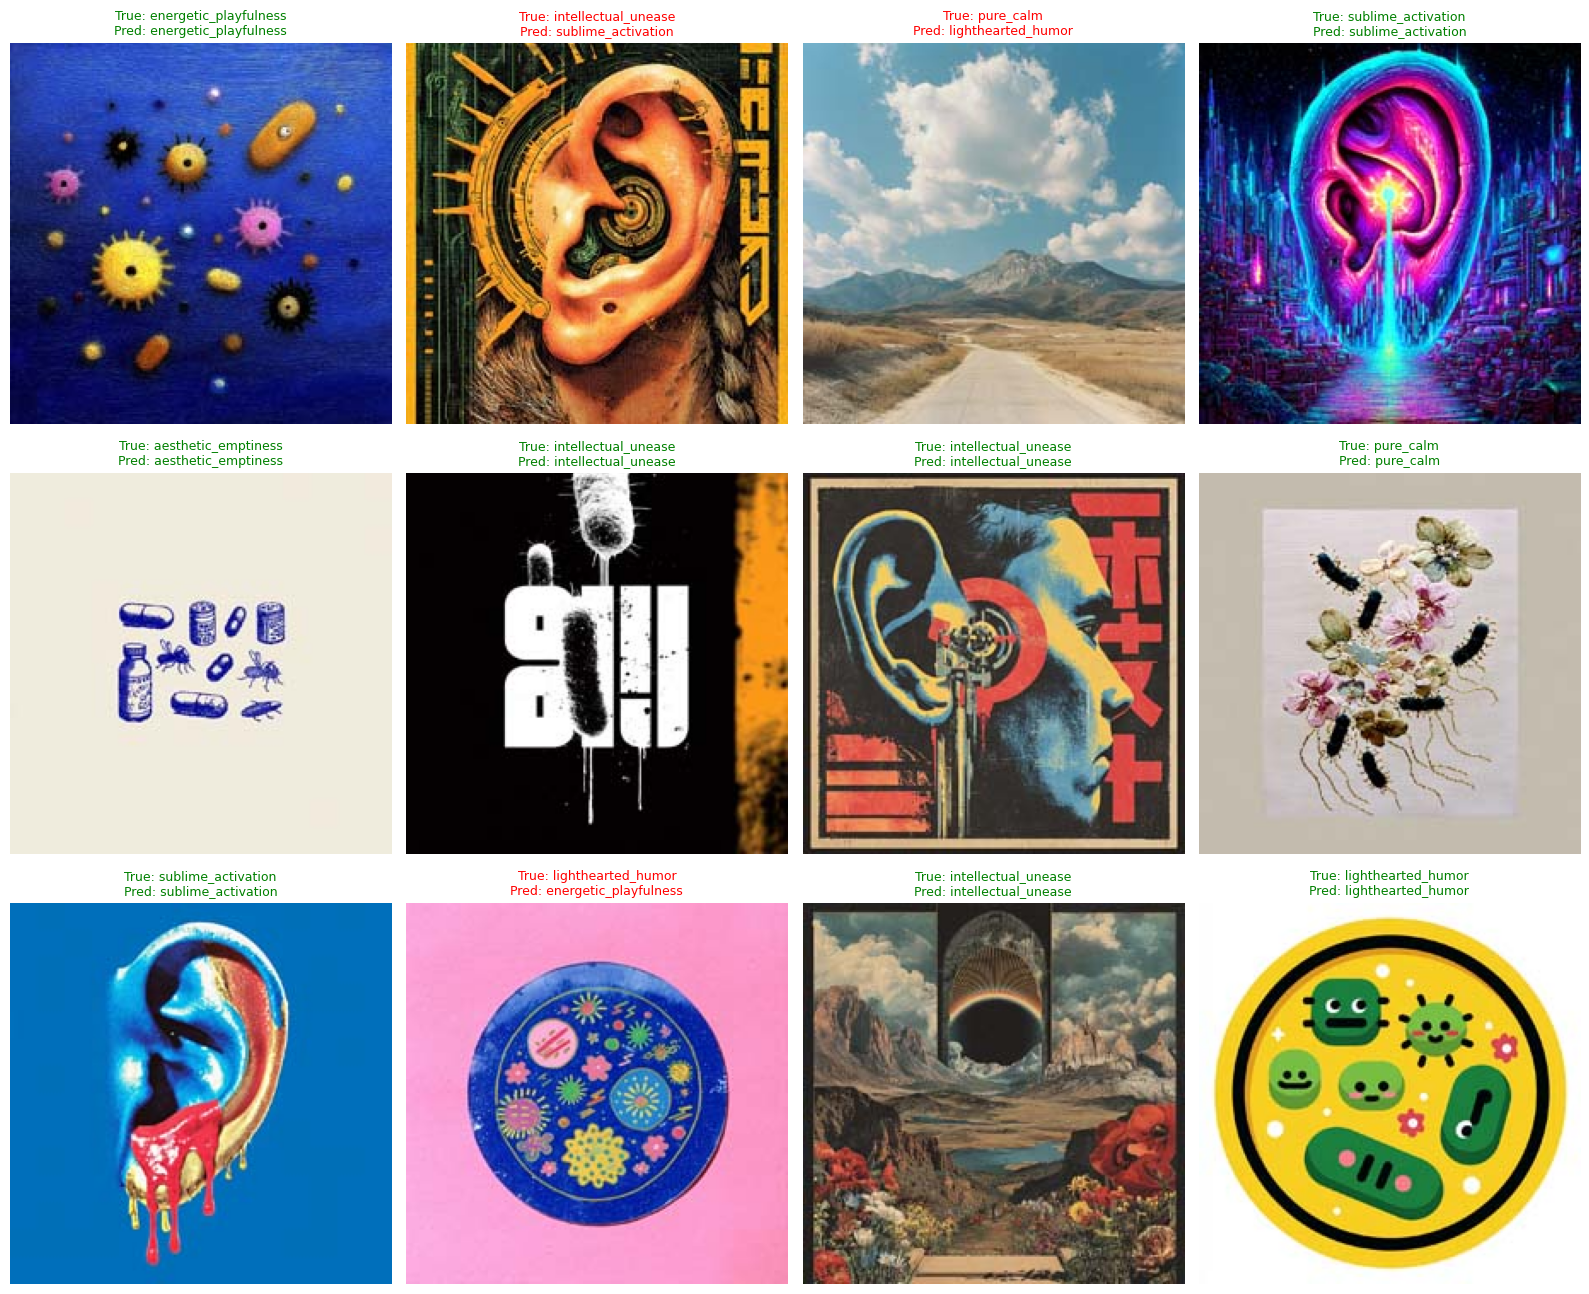

In [16]:
# Display a sample of test images with true and predicted labels.
def plot_test_predictions(test_dataset, test_metrics, label_names, num_images=12, seed=RANDOM_STATE):
    num_images = min(num_images, len(test_dataset), len(test_metrics["y_true"]))
    rng = np.random.default_rng(seed)
    sample_indices = rng.choice(len(test_dataset), size=num_images, replace=False)

    n_cols = 4
    n_rows = int(np.ceil(num_images / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4.4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, idx in zip(axes, sample_indices):
        sample = test_dataset[int(idx)]

        style = sample["style"]
        motif = sample["motif"]
        instance = sample["instance"]

        print(
            f"Index {idx}: "
            f"style={style}, motif={motif}, instance={instance}"
        )

        image = sample["image"].convert("RGB")
        true_label = label_names[test_metrics["y_true"][int(idx)]]
        pred_label = label_names[test_metrics["y_pred"][int(idx)]]
        is_correct = true_label == pred_label

        ax.imshow(image)
        ax.set_title(
            # f"Style: {style}\n"
            # f"Motif: {motif} | Instance: {instance}\n"
            f"True: {true_label}\nPred: {pred_label}",
            color="green" if is_correct else "red",
            fontsize=9,
        )
        ax.axis("off")

    for ax in axes[num_images:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


plot_test_predictions(test_dataset, test_metrics, label_names)


In [ ]:
# Load the rough human survey baseline for context.
# The survey used N=5 participants on 32 images: 4 per cluster, split evenly across antibiotics and landscape.
if HUMAN_BASELINE_PATH.exists():
    human_baseline_df = pd.read_csv(HUMAN_BASELINE_PATH)
    display(human_baseline_df)

    human_baseline_summary = human_baseline_df.set_index("Column")["Mean"]
    print("Human survey baseline mean metrics on the 32-image subset")
    print(f"Accuracy: {human_baseline_summary.get('Accuracy', np.nan):.4f}")
    print(f"Precision: {human_baseline_summary.get('Precision', np.nan):.4f}")
    print(f"Recall: {human_baseline_summary.get('Recall', np.nan):.4f}")
    print(f"F-measure: {human_baseline_summary.get('F-measure', np.nan):.4f}")
else:
    human_baseline_df = pd.DataFrame()
    print(f"Human baseline file not found at {HUMAN_BASELINE_PATH}.")


## Comparative Analysis

[Compare the performance of your model(s) against the baseline model. Discuss any improvements or setbacks and the reasons behind them.]

The baseline custom CNN reached 47.15% test accuracy and 0.4593 F1 score. Adding k-fold validation made the estimate more reliable but did not by itself create a major performance improvement. Optuna tuning improved the training setup but did not outperform the transfer-learning approach. AlexNet transfer learning and HSV preprocessing were also tested; neither improved on the ResNet50 model.

The human survey baseline gives an additional estimate of task difficulty: across 5 participants assigning a 32-image stratified subset to the same clusters, mean accuracy was 33.75% and mean F-measure was 0.3868. The subset contains 4 images per emotion cluster, split into 2 `antibiotics` images and 2 `landscape` images per cluster. This result should be interpreted cautiously because the survey subset differs from the full held-out test split used for the model metrics.

The ImageNet-normalized ResNet50 model is therefore the selected final model. Its best recorded test accuracy is about 56.1%, with a weighted F1 of about 0.564 and macro F1 of about 0.528 in the saved evaluation metrics. The improvement is plausible because ResNet50 starts from stronger pretrained visual representations, while the custom CNN must learn low-level and high-level visual features from the seminar dataset alone. Remaining limitations are visible in macro F1 and the confusion matrix: some emotion classes remain difficult to separate, which suggests overlap in visual aesthetics and label semantics.


In [ ]:
# Comparative Analysis code (if applicable)
# Example: comparing accuracy of the baseline model and the new model
# print(f"Baseline Model Accuracy: {baseline_accuracy}, New Model Accuracy: {new_model_accuracy}")

comparison_rows = [
    {
        "model": "Custom CNN baseline",
        "source": "2_BaselineModel/README.md",
        "evaluation_scope": "Full held-out test split",
        "accuracy": 0.4715,
        "f1_score": 0.4593,
        "macro_f1": np.nan,
        "notes": "Initial baseline without k-fold CV; F1 is weighted F1.",
    },
]

artifact_metrics = [
    (
        "Custom CNN + k-fold",
        ARTIFACT_DIR / "eval_eval_metrics_seed_42_w_k-fold.csv",
        "Grouped k-fold training, custom CNN; F1 is weighted F1.",
    ),
    (
        "ResNet50 transfer learning",
        EVAL_METRICS_PATH,
        "Selected final model with ImageNet normalization; F1 is weighted F1.",
    ),
    (
        "AlexNet transfer learning",
        ARTIFACT_DIR / "eval_eval_metrics_seed_42_w_k-fold_transfer_learning_alexnet_imagenet_normalized.csv",
        "Transfer-learning alternative; did not improve over ResNet50; F1 is weighted F1.",
    ),
]

for model_name, metrics_path, notes in artifact_metrics:
    if metrics_path.exists():
        metrics_df = pd.read_csv(metrics_path)
        best_row = metrics_df.loc[metrics_df["val_f1_weighted"].idxmax()]
        comparison_rows.append({
            "model": model_name,
            "source": str(metrics_path),
            "evaluation_scope": "Full held-out test split",
            "accuracy": best_row["val_accuracy"],
            "f1_score": best_row["val_f1_weighted"],
            "macro_f1": best_row["val_f1_macro"],
            "notes": notes,
        })

if HUMAN_BASELINE_PATH.exists():
    human_baseline_df = pd.read_csv(HUMAN_BASELINE_PATH)
    human_means = human_baseline_df.set_index("Column")["Mean"]
    comparison_rows.append({
        "model": "Human survey baseline",
        "source": str(HUMAN_BASELINE_PATH),
        "evaluation_scope": "32-image subset; 4 per cluster, split evenly across antibiotics and landscape; N=5 participants",
        "accuracy": human_means.get("Accuracy", np.nan),
        "f1_score": human_means.get("F-measure", np.nan),
        "macro_f1": np.nan,
        "notes": "Rough human context only; subset differs from the model test split.",
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("f1_score", ascending=False)
display(comparison_df.reset_index(drop=True))

full_test_df = comparison_df[comparison_df["evaluation_scope"] == "Full held-out test split"]
best_model = full_test_df.iloc[full_test_df["f1_score"].argmax()]
print(
    f"Best full-test model by weighted F1: {best_model['model']} "
    f"(accuracy={best_model['accuracy']:.4f}, weighted_f1={best_model['f1_score']:.4f})."
)

